# IT0004 — Binary Encoding
**Member 4 — Preprocessing Technique: Binary Encoding**

Course: IT2011 — Artificial Intelligence and Machine Learning (SLIIT, Year 2, Semester 1)

This notebook is **fully independent**: it loads the raw dataset directly and performs its own
missing-value handling and its own encoding technique from start to finish.

> Requires: `pip install category_encoders`

## 1. Introduction

**Binary Encoding** first ordinal-encodes each category to an integer, then represents that
integer as a binary code split across multiple 0/1 columns (e.g. category 5 -> `101`). This
needs only `ceil(log2(n_categories))` columns per feature instead of `n_categories - 1` columns
as one-hot would — a good middle ground that balances dimensionality against not implying a
false linear ordering the way plain label/ordinal encoding does.

## 2. Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/mushrooms.csv')
print("Shape:", df.shape)
df.head()

Shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## 3. Handle Missing Values & Drop Useless Column

**Missing-value strategy chosen: mode imputation.**
Mode imputation is chosen for simplicity and because it keeps all rows — binary encoding will
then represent the imputed mode with the same binary code as any naturally-occurring value of
that category, with no special handling required.

In [2]:
df = df.replace('?', np.nan)

print("Missing value counts per column:")
print(df.isnull().sum())
print()
print("Missing value percentage per column:")
print((df.isnull().sum() / len(df) * 100).round(2))

# veil-type has only 1 unique value across the whole dataset -> no predictive
# information at all, so every member drops it after noting this.
print()
print("veil-type unique values:", df['veil-type'].unique())
df = df.drop(columns=['veil-type'])

# Strategy: mode imputation for stalk-root
mode_value = df['stalk-root'].mode()[0]
print("Mode of stalk-root:", mode_value)
df['stalk-root'] = df['stalk-root'].fillna(mode_value)

print()
print("Missing values remaining:", df.isnull().sum().sum())

Missing value counts per column:
class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

Missing value percentage per column:
class                        0.00
cap-shape                    0.00
cap-surface                  0.00
cap-color                    0.00
bruises              

/var/folders/ln/lpsmr0qd3673cmmw327l0g1m0000gn/T/ipykernel_27632/2033130353.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['stalk-root'].fillna(mode_value, inplace=True)


## 4. Apply Binary Encoding

`category_encoders.BinaryEncoder` is applied to all feature columns.

In [3]:
# pip install category_encoders
import category_encoders as ce

feature_cols = [c for c in df.columns if c != 'class']
shape_before = df.shape
print("Shape before binary encoding:", shape_before)

encoder = ce.BinaryEncoder(cols=feature_cols)
df_encoded = encoder.fit_transform(df[feature_cols])
df = pd.concat([df_encoded, df['class']], axis=1)

print("Shape after binary encoding:", df.shape)
df.head()

Shape before binary encoding: (8124, 22)
Shape after binary encoding: (8124, 64)


,cap-shape_0,cap-shape_1,cap-shape_2,cap-surface_0,cap-surface_1,cap-surface_2,cap-color_0,cap-color_1,cap-color_2,cap-color_3,...,spore-print-color_1,spore-print-color_2,spore-print-color_3,population_0,population_1,population_2,habitat_0,habitat_1,habitat_2,class
0,0,0,1,0,0,1,0,0,0,1,...,0,0,1,0,0,1,0,0,1,p
1,0,0,1,0,0,1,0,0,1,0,...,0,1,0,0,1,0,0,1,0,e
2,0,1,0,0,0,1,0,0,1,1,...,0,1,0,0,1,0,0,1,1,e
3,0,0,1,0,1,0,0,0,1,1,...,0,0,1,0,0,1,0,0,1,p
4,0,0,1,0,0,1,0,1,0,0,...,0,1,0,0,1,1,0,1,0,e


**How binary encoding works:** each category is first assigned an ordinal integer
(e.g. 22 categories in `gill-color` -> integers 0-21). That integer is then written in binary
and each bit becomes its own column (e.g. `ceil(log2(22)) = 5` columns instead of 21 one-hot
columns). This gives a **much smaller column count than one-hot encoding** (~50 columns here
vs 90+ for one-hot) while still avoiding the false-ordering problem of a single raw integer
column, making it a reasonable middle ground for models sensitive to dimensionality.

## 5. Encode Target Variable

In [4]:
df['class'] = df['class'].map({'e': 0, 'p': 1})
print(df['class'].value_counts())
print()
print("Class balance (%):")
print((df['class'].value_counts(normalize=True) * 100).round(2))

class
0    4208
1    3916
Name: count, dtype: int64

Class balance (%):
class
0    51.8
1    48.2
Name: proportion, dtype: float64


## 6. EDA Visualization

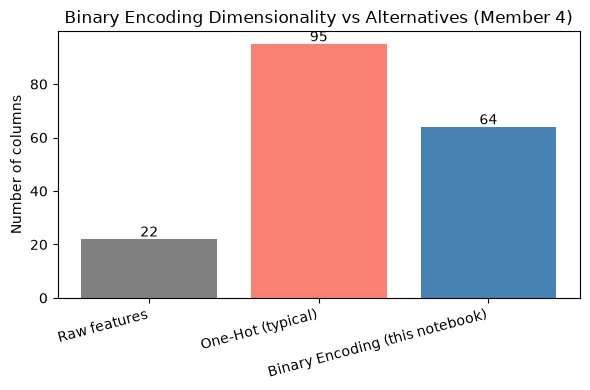

In [5]:
import os
os.makedirs('../results/eda_visualizations', exist_ok=True)

counts = {'Raw features': 22, 'One-Hot (typical)': 95, 'Binary Encoding (this notebook)': df.shape[1]}
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.keys(), counts.values(), color=['gray', 'salmon', 'steelblue'])
ax.set_ylabel('Number of columns')
ax.set_title('Binary Encoding Dimensionality vs Alternatives (Member 4)')
plt.xticks(rotation=15, ha='right')
for i, v in enumerate(counts.values()):
    ax.text(i, v + 1, str(v), ha='center')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/M4_binary_encoding.png', dpi=150)
plt.show()

## 7. Save Output

In [6]:
os.makedirs('../results/outputs', exist_ok=True)
df.to_csv('../results/outputs/step_M4_binary_encoded.csv', index=False)
print("Saved: ../results/outputs/step_M4_binary_encoded.csv")
print("Final shape:", df.shape)

Saved: ../results/outputs/step_M4_binary_encoded.csv
Final shape: (8124, 64)
